# 01 - EDA, Feature Engineering, and Baseline Model

This notebook explores the stellar classification dataset and builds the first validation baseline. The goal is to understand the target distribution, inspect feature behavior, test simple feature engineering ideas, and identify a strong feature set for the model-selection notebook.

The main outputs of this notebook are:

- evidence for using stratified validation and balanced accuracy
- a compact feature set built from redshift, photometric bands, and encoded position
- an initial LightGBM baseline
- a first probability-weighted submission

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

In [3]:
df = pd.read_csv("../data/train.csv", index_col=False)
df = df.drop(columns="id")

In [4]:
print(df.shape)
print(df.duplicated().sum())
df.info()

(577347, 11)
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              577347 non-null  float64
 1   delta              577347 non-null  float64
 2   u                  577347 non-null  float64
 3   g                  577347 non-null  float64
 4   r                  577347 non-null  float64
 5   i                  577347 non-null  float64
 6   z                  577347 non-null  float64
 7   redshift           577347 non-null  float64
 8   spectral_type      577347 non-null  object 
 9   galaxy_population  577347 non-null  object 
 10  class              577347 non-null  object 
dtypes: float64(8), object(3)
memory usage: 48.5+ MB


In [5]:
df.head(10)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


#### Takeaways:
- The dataset is large, with 577,347 rows and 11 columns after dropping 'id'.
- There are no duplicate rows.
- The input data contains 8 numeric features and 2 categorical features.
- The target variable, 'class', is categorical and will be modeled as a multiclass classification problem.

#### Check target class distribution

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

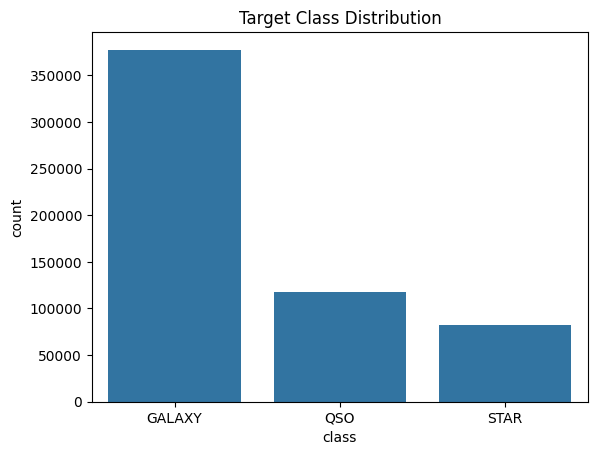

In [6]:
class_counts = df['class'].value_counts()
class_proportions = df['class'].value_counts(normalize=True)

display(class_counts)
display(class_proportions)

sns.countplot(data=df, x="class")
plt.title("Target Class Distribution")
plt.show()

#### Categorical Feature Counts

In [7]:
display(df['spectral_type'].value_counts())
display(df['galaxy_population'].value_counts())

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

#### Takeaways:
- The target is moderately imbalanced: GALAXY makes up 65% of the training data.
- Future train/validation splits should use stratification to preserve class proportions.
- Accuracy alone may be misleading, so log loss and class-level performance should be checked.

#### Categorical Features vs Target



In [8]:
display(pd.crosstab(df["spectral_type"], df["class"], normalize="index"))
pd.crosstab(df["galaxy_population"], df["class"], normalize="index")

class,GALAXY,QSO,STAR
spectral_type,,,
A/F,0.198490,0.503709,0.297801
G/K,0.567750,0.192739,0.239511
M,0.949559,0.012821,0.037620
O/B,0.082803,0.710836,0.206361


class,GALAXY,QSO,STAR
galaxy_population,,,
Blue_Cloud,0.345106,0.420022,0.234873
Red_Sequence,0.902846,0.027753,0.069401


#### Takeaways:
- `spectral_type` appears strongly related to the target. M-type observations are mostly GALAXY, whereas O/B observations are mostly QSO.
- `galaxy_population` is also informative: Red_sequence is mostly GALAXY, whilst Blue_Cloud is more mixed across classes.
- Both features appear related to the target and should be tested in ablation.

#### Numeric Feature Averages by Target Class

In [9]:
numerical_features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
df.groupby("class")[numerical_features].mean()

,alpha,delta,u,g,r,i,z,redshift
class,,,,,,,,
GALAXY,178.557241,21.033443,22.989160,21.270147,19.860511,19.068222,18.629897,0.509026
QSO,189.665998,25.811829,21.724756,21.160314,20.918809,20.767309,20.602139,1.875641
STAR,184.178832,19.858725,20.960388,19.591033,19.075853,18.830555,18.707180,0.068115


#### Takeaways:
- `redshift` differs substantially by class, especially QSO compared to GALAXY and STAR.
- Further insights need visualizations of distributions.

#### Visualizing the Distributions

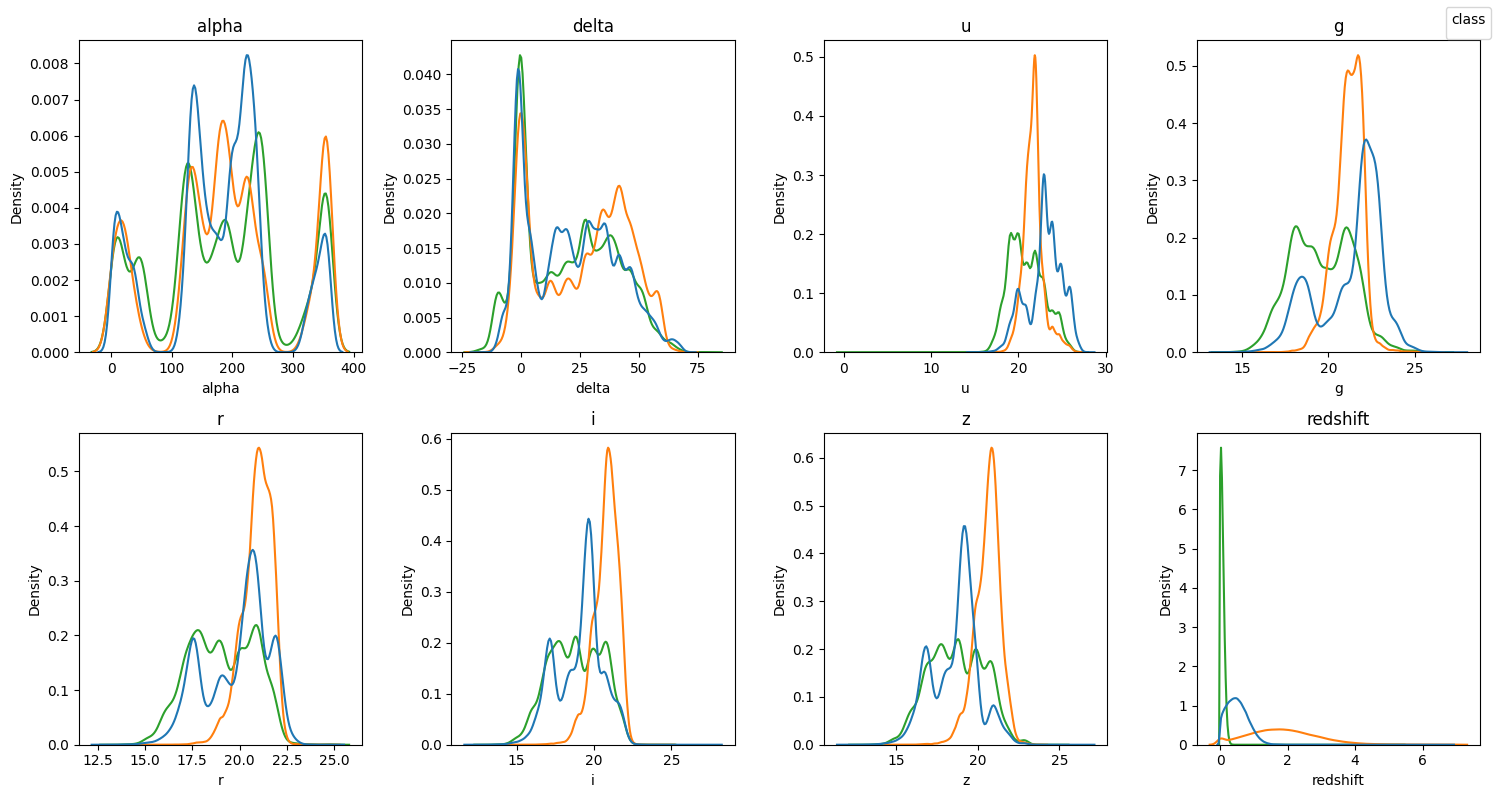

In [10]:
fig, axes = plt.subplots(2,4, figsize=(15,8))
axes = axes.ravel()

for ax, col in zip(axes, numerical_features):
    
    sns.kdeplot(data=df, x=col, hue="class", common_norm=False, ax=ax, legend=False)
    ax.set_title(col)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="class", loc="upper right")
plt.tight_layout()
plt.show()

#### Takeaways:
- `alpha` and `delta` have broadly similar distributions across classes, but some regions may still provide useful signals.
- The photometric bands show visible class separation, especially as wavelength increases from `u` toward `z`.
- `i` and `z` are incredibly similar distributions, so it is worth testing whether removing one affects validation performance.
- `redshift` appears highly informative, especially for separating STAR from QSO and GALAXY.

Encoding alpha with the sine function is important due to them being recorded in degrees. The model will not be able to tell that 360 and 0 are the same. Delta does not have the same issue as it seems to be within -25 to 75 degrees.

In [11]:
alpha_rad = np.deg2rad(df["alpha"])
df["alpha_sin"] = np.sin(alpha_rad)
df["alpha_cos"] = np.cos(alpha_rad)

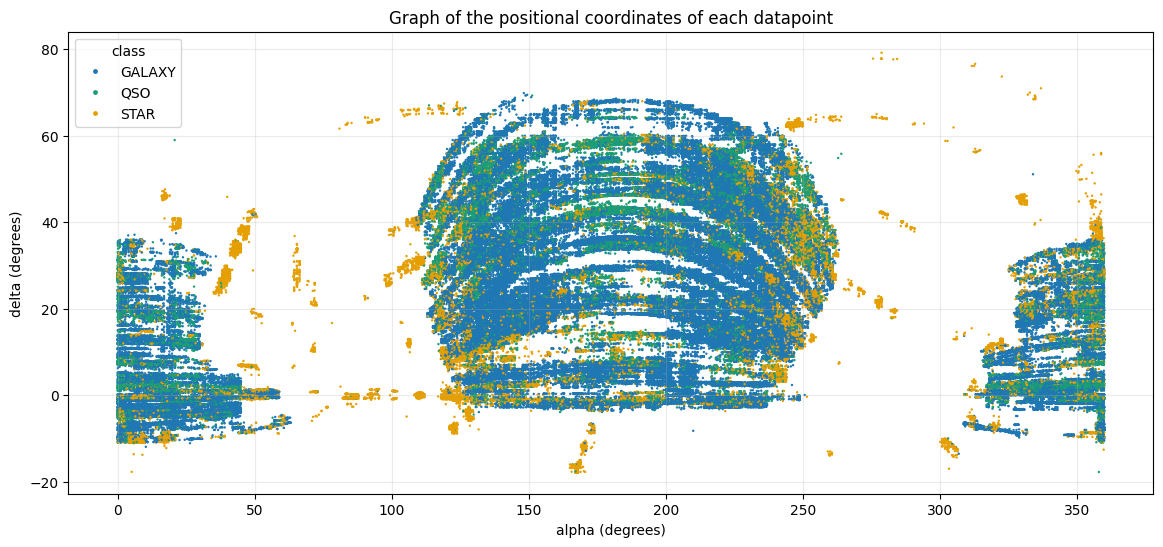

In [12]:
palette = {
    "GALAXY": "#1f77b4",
    "QSO": "#1b9e77",
    "STAR": "#e69f00"
}

#plot_df = df.sample(50000, random_state=42)

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="alpha",
    y="delta",
    hue="class",
    palette=palette,
    alpha=1,
    s=3,
    linewidth=0
)

plt.title("Graph of the positional coordinates of each datapoint")
plt.xlabel("alpha (degrees)")
plt.ylabel("delta (degrees)")
plt.legend(title="class", markerscale=2)
plt.grid(True, alpha=0.25)

plt.show()

Graphing alpha and delta reveals a graph that doesn't show great promise for predictive power. This will be further tested in an ablation study.

#### Experimenting with Photometric differences

In [13]:
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]
df["u_z"] = df["u"] - df["z"]

In [14]:
colour_mix = ['u_g', 'g_r', 'r_i', 'i_z', 'u_z']
df.groupby("class")[colour_mix].mean()

,u_g,g_r,r_i,i_z,u_z
class,,,,,
GALAXY,1.719013,1.409635,0.792290,0.438324,4.359263
QSO,0.564442,0.241505,0.151500,0.165170,1.122616
STAR,1.369355,0.515179,0.245298,0.123375,2.253208


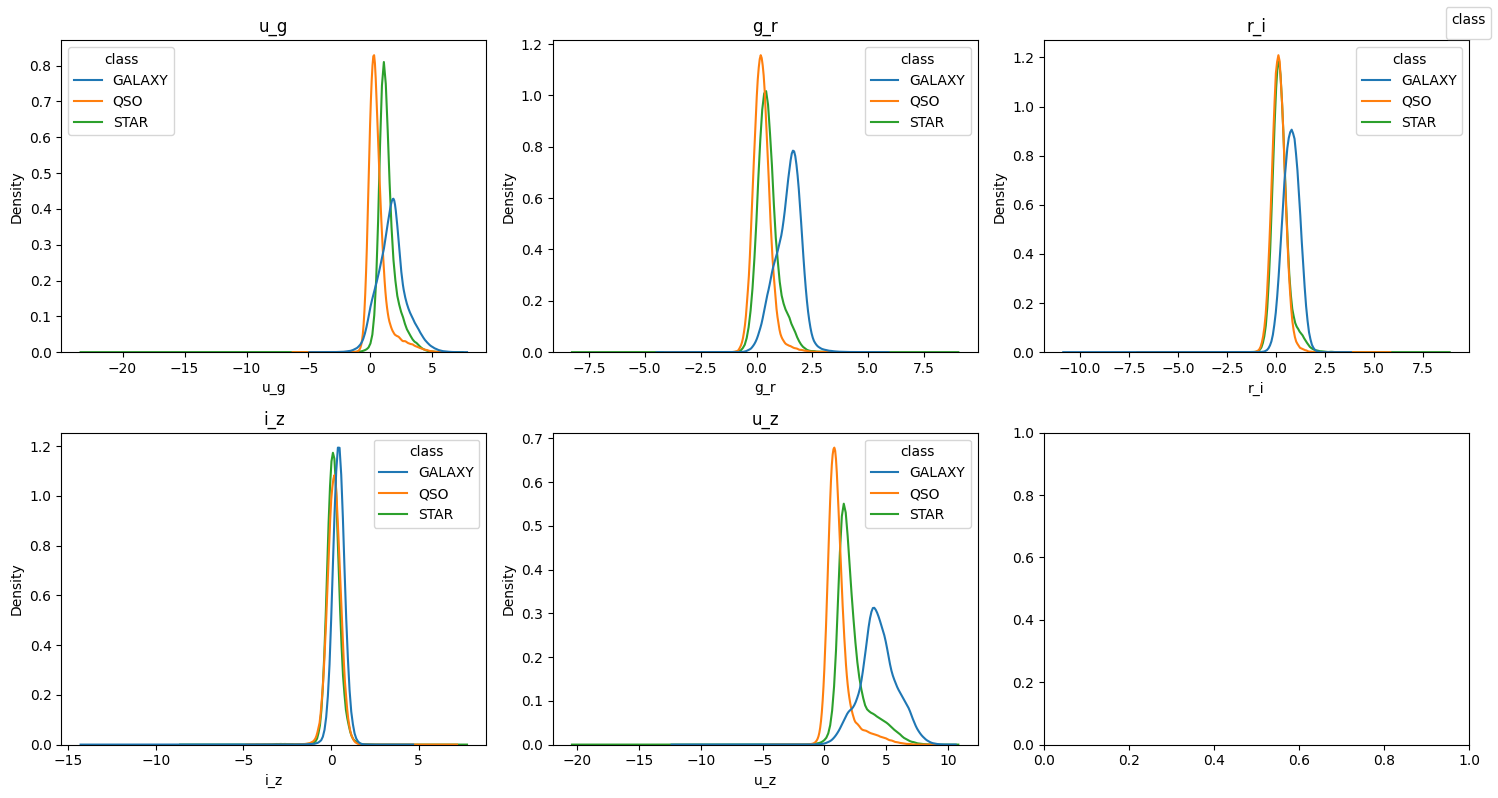

In [15]:
figs, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.ravel()

for ax, col, in zip(axes, colour_mix):
    sns.kdeplot(data=df, x=col, hue="class", ax=ax, common_norm=False)
    ax.set_title(col)

handles, labels = axes[0].get_legend_handles_labels()
figs.legend(handles, labels, title="class", loc="upper right")

plt.tight_layout()
plt.show()

#### Takeaways:
- The photometric differences help separate `GALAXY`.
- `u_g` and `u_z` are most informative for distinguishing `QSO` from `STAR`.
- These engineered features should be tested in the preprocessing experiments notebook

#### Correlation Heatmap

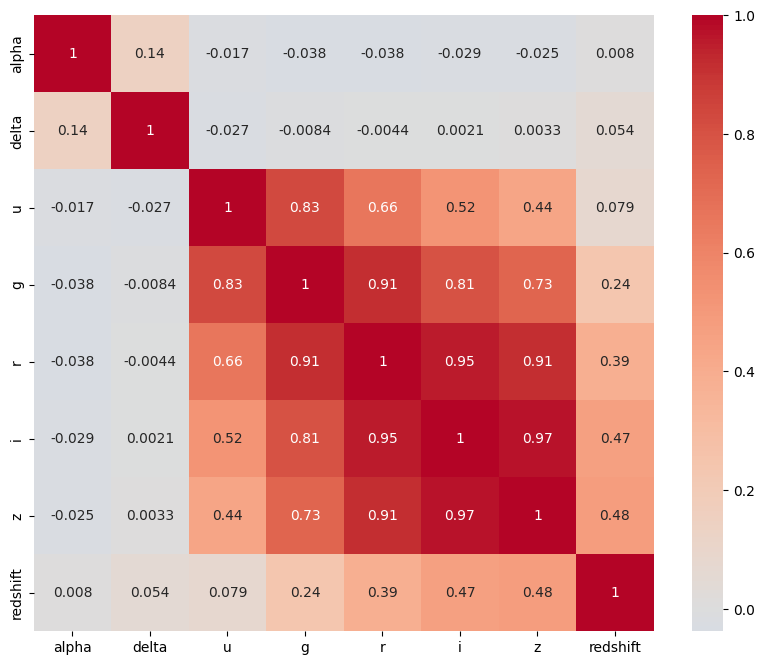

In [16]:
numeric_cols = df.select_dtypes("number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

#### Takeaways:
- `alpha` and `delta` are only slightly correlated with each other and mostly uncorrelated with other numeric features.
- The photometric bands are highly correlated, especially `r`, `i` and `z`. 
This suggests an ablation study of the photometric bands is worthwhile, but they should not be removed automatically because correlated bands may still contain useful information. 


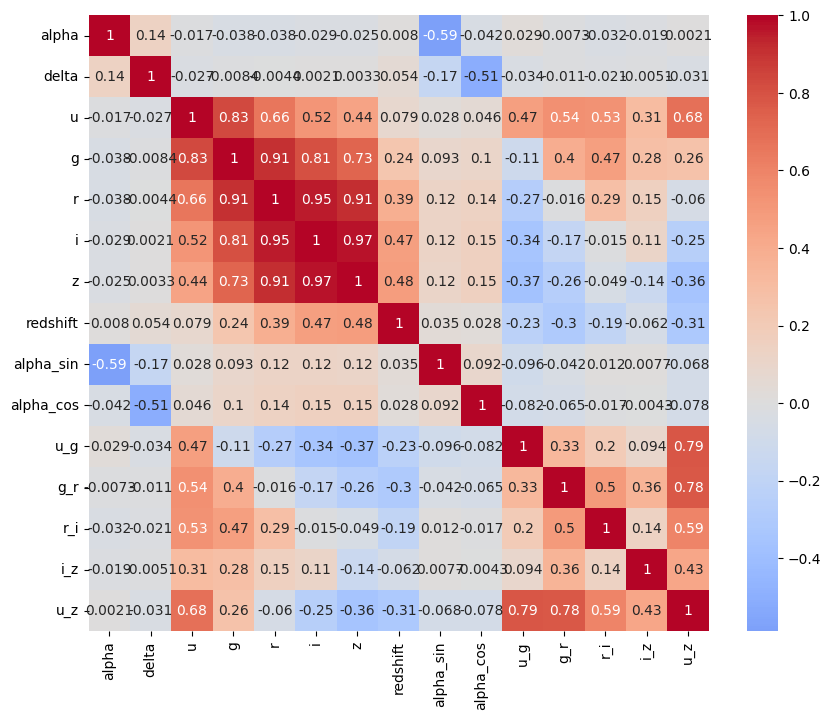

In [17]:
numeric_cols = df.select_dtypes("number").columns

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.show()

## Feature Group Ablation

The EDA suggests several candidate feature groups: redshift, photometric bands, position, synthetic categorical features, and photometric differences. I use a LightGBM baseline with stratified OOF validation to test which groups actually improve balanced accuracy.

In [2]:
from sklearn.model_selection import StratifiedKFold 
from sklearn.metrics import balanced_accuracy_score
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm

In [22]:
params = dict(
    objective="multiclass",
    num_class=3,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,          # row bagging
    subsample_freq=1,
    colsample_bytree=0.8,   # feature bagging
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1,
    verbose=-1
)

Each experiment below adds or swaps a feature group while keeping the model and cross-validation setup fixed. This isolates whether performance gains come from the features rather than model changes.

In [25]:
groups = {
    'baseline' : [],
    'redshift' : ['redshift'],
    'synthetic' : ['spectral_type', 'galaxy_population'],
    'colour' : ['u', 'g', 'r', 'i', 'z'],
    'position' : ['alpha_sin', 'alpha_cos', 'delta'],
    'colour mixes' : colour_mix,
}

experiments = {
    'redshift' : ['redshift'],
    #'+ diff colour' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z'],
    'redshift + colour' : ['redshift', 'u', 'g', 'r', 'i', 'z'],
    'colours mixes only + position' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'alpha', 'delta'],
    'both colours + position' : ['redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'u', 'g', 'r', 'i', 'z', 'alpha', 'delta'],
    'redshift + colour + position' : ['redshift', 'u', 'g', 'r', 'i', 'z', 'alpha', 'delta'],
    'encoded position instead' : ['redshift', 'u', 'g', 'r', 'i', 'z', 'alpha_sin', 'alpha_cos', 'delta'],
}
all_features = [f for group in groups.values()
                for f in group]

le = LabelEncoder()

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

df_lgbm = df.copy()

for col in ["spectral_type", "galaxy_population"]:
    df_lgbm[col] = df_lgbm[col].astype("category")

results = []
oofs = []
oofs_p = []
y = le.fit_transform(df_lgbm["class"])
for values in tqdm(experiments.values(), desc="feature_groups"):
    oof_preds = np.empty(len(y), dtype=object); temp = []
    oof_probs = np.empty((len(y), 3), dtype=object)
    #f = [x for x in all_features if x not in values] Removes
    X = df_lgbm[values]
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        
        X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y[train_idx], y[test_idx]
        cat_features = [
            col for col in groups["synthetic"]
            if col in X_train.columns
        ]
        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
        model = lgb.train(params, train_data)
        
        probs = model.predict(X_test)
        preds = probs.argmax(axis=1)
        oof_preds[test_idx] = preds; oof_probs[test_idx] = probs
        temp.append(balanced_accuracy_score(y_test, preds))
    results.append(temp)
    oofs.append(oof_preds)
    oofs_p.append(oof_probs)





feature_groups:   0%|          | 0/6 [00:00<?, ?it/s]

This test compares additive feature sets. Each row shows how validation performance changes as feature groups are added to the LightGBM baseline.


In [ ]:
for result, experiment in zip(results, experiments.keys()):
    mean = np.mean(result)
    std = np.std(result)
    print(f"{experiment} | mean: {mean} | std: {std}")


- Here we see that the removal of redshift significantly lowers the strength of the model. 
- Synthetic Features do not appear to have any impact on the strength of the model.
- Colour features have the second largest impact on performance.
- Position features and the colour mix features have only a slight impact on performance.

In [26]:
previous_mean = 0
for result, experiment in zip(results, experiments.keys()):
    mean = np.mean(result)
    std = np.std(result)
    print(f"{experiment} | mean: {mean} | std: {std} | increase in mean: {mean- previous_mean}")
    previous_mean = mean

redshift | mean: 0.8038329391866137 | std: 0.0030152335052945284 | increase in mean: 0.8038329391866137
redshift + colour | mean: 0.9362737522407911 | std: 0.00020387866153213991 | increase in mean: 0.13244081305417743
colours mixes only + position | mean: 0.9468911551149107 | std: 0.0008644912936198563 | increase in mean: 0.010617402874119608
both colours + position | mean: 0.955255493265898 | std: 0.0007353680039904629 | increase in mean: 0.00836433815098725
redshift + colour + position | mean: 0.9551811095476237 | std: 0.0007249305290833952 | increase in mean: -7.438371827428458e-05
encoded position instead | mean: 0.9557854002043957 | std: 0.0005312208551509186 | increase in mean: 0.000604290656772033


It seems that the core of redshift, colour, and position features create the strongest base with a performance of about 0.955. Encoding alpha does yield incremental increases in mean.

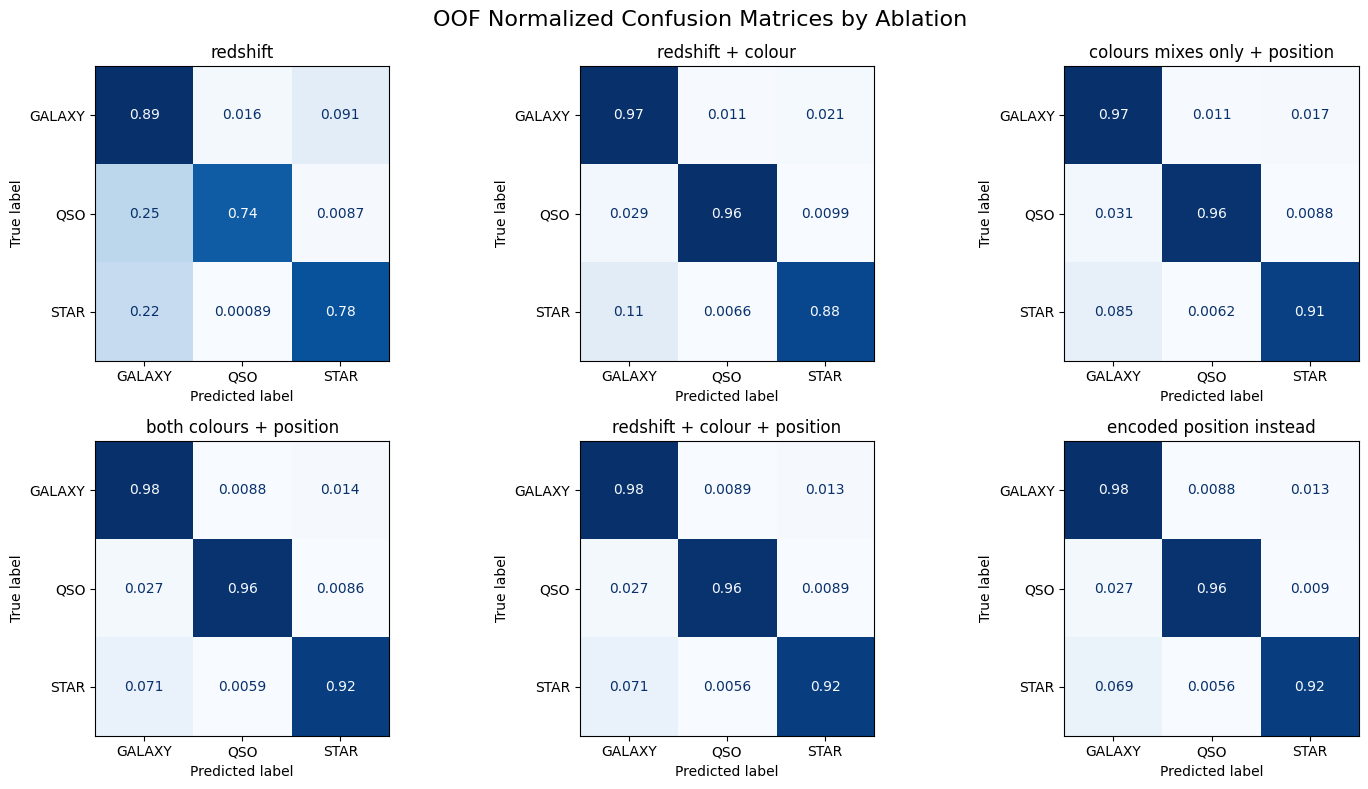

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

n = len(oofs)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.ravel()

for ax, oof_pred, experiment in zip(axes, oofs, experiments.keys()):
    ConfusionMatrixDisplay.from_predictions(
        le.inverse_transform(y),
        le.inverse_transform(oof_pred.astype(int)),
        normalize="true",
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{experiment}")

for ax in axes[len(oofs):]:
    ax.axis("off")

fig.suptitle("OOF Normalized Confusion Matrices by Ablation", fontsize=16)
plt.tight_layout()
plt.show()

Takeaways:
- redshift is very strong on GALAXY.
- When adding the colour features, you get a strong GALAXY and QSO predictor.
- STAR has the lowest recall and therefore offers the largest apparent opportunity for improvement.
- Positional metrics help STAR in a sizeable manner.
- Photometric difference features did not improve this LightGBM validation setup.

For a baseline, LightGBM is used together with a small probability-weighting post-process. The weights are tuned with differential evolution. To avoid reporting an optimistic score, the weight tuning is evaluated with a second CV loop over the out-of-fold probabilities: each fold learns weights on one slice of OOF predictions and evaluates those weights on held-out OOF predictions. LightGBM itself is not HPO'd here; that belongs in the next notebook.


In [30]:
from scipy.optimize import differential_evolution


def predict_with_class_weights(probs, weights):
    """Return class predictions after multiplying class probabilities by weights."""
    probs = np.asarray(probs, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return (probs * weights).argmax(axis=1)


def optimize_qso_star_weights(probs, y_true, seed=42):
    """Optimize QSO and STAR probability weights for balanced accuracy."""
    probs = np.asarray(probs, dtype=float)
    y_true = np.asarray(y_true)

    def objective(params):
        weights = np.array([1.0, params[0], params[1]])
        preds = predict_with_class_weights(probs, weights)
        return -balanced_accuracy_score(y_true, preds)

    result = differential_evolution(
        objective,
        bounds=[(0.5, 2.0), (0.5, 2.0)],
        seed=seed,
        tol=1e-7,
    )

    weights = np.array([1.0, result.x[0], result.x[1]])
    score = -result.fun
    return weights, score


base_experiment = "redshift + colour + position"
base_idx = list(experiments).index(base_experiment)
base_oof_probs = np.asarray(oofs_p[base_idx], dtype=float)
base_oof_preds = np.asarray(oofs[base_idx], dtype=int)

print(
    f"Unweighted {base_experiment} OOF balanced accuracy: "
    f"{balanced_accuracy_score(y, base_oof_preds):.6f}"
)


Unweighted redshift + colour + position OOF balanced accuracy: 0.955181


In [31]:
skf_de = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2,
)

calibrated_oof_preds = np.empty(len(y), dtype=int)
fold_weight_rows = []

for fold, (train_idx, valid_idx) in tqdm(enumerate(skf_de.split(base_oof_probs, y), start=1)):
    fold_weights, inner_score = optimize_qso_star_weights(
        base_oof_probs[train_idx],
        y[train_idx],
        seed=fold,
    )

    valid_preds = predict_with_class_weights(base_oof_probs[valid_idx], fold_weights)
    calibrated_oof_preds[valid_idx] = valid_preds
    valid_score = balanced_accuracy_score(y[valid_idx], valid_preds)

    fold_weight_rows.append({
        "fold": fold,
        "qso_weight": fold_weights[1],
        "star_weight": fold_weights[2],
        "inner_train_score": inner_score,
        "heldout_score": valid_score,
    })

weight_cv_results = pd.DataFrame(fold_weight_rows)
display(weight_cv_results)

cv_weighted_score = balanced_accuracy_score(y, calibrated_oof_preds)
print(f"CV-estimated weighted OOF balanced accuracy: {cv_weighted_score:.6f}")

best_weights, best_score = optimize_qso_star_weights(base_oof_probs, y, seed=42)
print("Final weights fit on all OOF probabilities:", best_weights)
print(f"In-sample weighted OOF score for final-weight selection: {best_score:.6f}")


,fold,qso_weight,star_weight,inner_train_score,heldout_score
0,1,1.939154,1.996314,0.962360,0.963016
1,2,1.937667,1.994226,0.962341,0.963078
2,3,1.937739,1.994759,0.962626,0.961958
3,4,1.937964,1.999809,0.962339,0.963079
4,5,1.937386,1.994777,0.962794,0.961269


CV-estimated weighted OOF balanced accuracy: 0.962480
Final weights fit on all OOF probabilities: [1.         1.93916436 1.99667318]
In-sample weighted OOF score for final-weight selection: 0.962491


In [35]:
rX_test = pd.read_csv("../data/test.csv", index_col=False)

In [36]:
rX_test = rX_test.drop(columns=['spectral_type', 'galaxy_population'])
ids = rX_test.pop('id')
alpha_rad = np.deg2rad(rX_test["alpha"])
rX_test["alpha_sin"] = np.sin(alpha_rad)
rX_test["alpha_cos"] = np.cos(alpha_rad)

rX_test = rX_test[experiments['encoded position instead']]

In [37]:
final_X = df[experiments['encoded position instead']]
train_data = lgb.Dataset(final_X, label=y)
model = lgb.train(params, train_data)
probs = model.predict(rX_test)
adjusted_probs = probs * best_weights
preds = adjusted_probs.argmax(axis=1)

test_pred_labels = le.inverse_transform(preds)

submissions = pd.DataFrame(
    {
        'id': ids,
        'class': test_pred_labels
    }
)
submissions.to_csv("basic_attempt_submission.csv", index=False)

This submission had a public score of 0.9643 and private score of 0.9635. For context this is around 50% mark (1427/2816).

## Notebook 01 Conclusions

The strongest baseline feature set uses redshift, the original photometric bands, and encoded positional features. Synthetic categorical features and photometric differences appeared less useful in validation, so notebook 02 focuses on model comparison and tuning using the compact feature set.

The baseline LightGBM + probability weighting submission scored 0.9643 public / 0.9635 private, giving a useful benchmark for later model-selection work.

## Acknowledgements

Some EDA ideas were inspired by Georgy Mamarin’s “An almost-exhaustive Stellar Class EDA [final]” Kaggle notebook. All experiments were independently implemented and extended for this project. https://www.kaggle.com/code/georgymamarin/an-almost-exhaustive-stellar-class-eda-final.